# Humpback Whale Identification — Contrastive Loss Metric Learning

**Course**: Machine Learning for Computer Vision (91266)  
**Task**: [Kaggle Whale Identification Playground](https://www.kaggle.com/competitions/whale-categorization-playground)  
**Authors**: Kristoffer Osen & Sebastian Munthe


## Setup

In [1]:
import sys
import os
import torch
import json
from dataset import build_retrieval_eval_loaders
from dataset import get_eval_config_and_data
from visualization import plot_embedding_tsne


sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

from config import ExperimentConfig
from experiment import ExperimentManager
from dataset import (
    prepare_data,
    build_dataloaders,
 )
from models import build_model
from training import train
from evaluation import evaluate_retrieval
from visualization import plot_training_history

device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
                      else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA RTX PRO 4000 Blackwell


## Contrastive Loss Training

**Contrastive Loss** operates on **pairs** rather
than triplets. For each pair of embeddings, the loss pulls same-class pairs together and
pushes different-class pairs apart:

$$L = (1 - y) \cdot \tfrac{1}{2} \max\{0,\ D - m^+\}^2 \;+\; y \cdot \tfrac{1}{2} \max\{0,\ m^- - D\}^2$$

where $D = \|f(x_i) - f(x_j)\|$ is the Euclidean distance, $y = 0$ for positive pairs
(same class) and $y = 1$ for negative pairs (different class).

Key implementation details:
- **Positive margin $m^+$**: without it, the model is incentivized to collapse all
  same-class embeddings to a single point. The positive margin creates a "good enough"
  threshold — once a positive pair is closer than $m^+$, the gradient stops and the model
  can spend capacity on harder problems.
- **Dead zone**: because $m^+ < m^-$, there is a range of distances where neither branch
  produces gradient, which stabilizes training.
- **PK Sampling**: same rationale as triplet — each batch needs P identities × K images
  to guarantee positive pairs exist. Without it, random batches may contain mostly
  singletons and produce almost no positive-pair signal.
- **Same limitation as triplet**: classes with only 1 image cannot form positive pairs
  and are effectively skipped during training.

The model uses `head_type="none"` — no classifier, only the L2-normalized embedding.
Validation uses retrieval recall (nearest-neighbor in embedding space) rather than
classification accuracy.

In [2]:
config = ExperimentConfig(
    # ── Metadata ─────────────────────────────────────────────────
    experiment_name="contrastive_effnetb5",
    description="Contrastive loss with positive margin, PK sampling",

    # ── Paths ────────────────────────────────────────────────────
    data_dir="data",
    experiments_root="experiments",

    # ── Model ────────────────────────────────────────────────────
    backbone="efficientnet_b5",
    image_size=(456, 456),
    embedding_dim=512,
    head_type="none",          # No classifier, embedding-only

    # ── Training ─────────────────────────────────────────────────
    freeze_backbone_epochs=3,
    freeze_bn=True,
    epochs=25,
    batch_size=8,              
    accumulation_steps=2,     
    use_amp=True,

    # ── PK Sampling ──────────────────────────────────────────────
    pk_sampling=True,
    pk_p=4,                   
    pk_k=4,                    
    pk_min_samples=2,         

    # ── Loss ─────────────────────────────────────────────────────
    loss_type="contrastive",
    contrastive_pos_margin=0.2,
    contrastive_neg_margin=1.0,
    use_class_weights=False,  

    # ── Optimizer ────────────────────────────────────────────────
    lr_head=5e-4,
    lr_backbone=5e-5,
    weight_decay=1e-4,

    # ── Scheduler ────────────────────────────────────────────────
    scheduler="cosine",
    warmup_epochs=1,

    # ── Early stopping ───────────────────────────────────────────
    early_stopping_patience=6,
    early_stopping_metric="retrieval_recall@1",

    # ── Initialize from baseline ─────────────────────────────────
    init_from_checkpoint=BASELINE_CHECKPOINT if 'BASELINE_CHECKPOINT' in dir() else None,

    seed=42,
)

print("Contrastive config:")
print(config.summary())


Contrastive config:
efficientnet_b5 | 456px | contrastive(γ=2.0) | lr=5e-05/0.0005 | freeze=3ep | bs=8×2 | head=none | contrastive(m+=0.2,m-=1.0) | PK(4×4)


## Data Preparation

In [3]:
data = prepare_data(config)

print(f"\nClass mapping: {data['num_classes']} known whale identities")
print(f"ID → Index examples: {dict(list(data['id_to_idx'].items())[:5])} ...")

train_loader, val_loader = build_dataloaders(config, data)

[split] Stratified test split infeasible on frequent classes; using shuffled split.
[split] Stratified val split infeasible on frequent classes; using shuffled split.
Dataset split:
  Train:    8089 images, 4247 known classes (filtered 647 new_whale)
  Val:       557 images (88 are new_whale)
  Test:      557 images (75 are new_whale)
  Class distribution: min=1 median=1 max=24 samples/class

Class mapping: 4247 known whale identities
ID → Index examples: {'w_0013924': 0, 'w_001ebbc': 1, 'w_002222a': 2, 'w_002b682': 3, 'w_002dc11': 4} ...


## Train

In [4]:
TRAINING_ENABLED = True
EXPERIMENT_ID = "unknown"

if TRAINING_ENABLED:
    # manager = train(config, data, device, resume_from=EXPERIMENT_ID)
    manager = train(config, data, device)
else:
    print("Skipping training")
    config = ExperimentConfig.load("experiments/" + EXPERIMENT_ID + "/config.json")
    manager = ExperimentManager(config, EXPERIMENT_ID)

[11:48:03] New experiment: 20260525_114803_contrastive_effnetb5_3a9bca2e
[11:48:03] Config: efficientnet_b5 | 456px | contrastive(γ=2.0) | lr=5e-05/0.0005 | freeze=3ep | bs=8×2 | head=none | contrastive(m+=0.2,m-=1.0) | PK(4×4)
[11:48:03] No matching resume target found. Starting new experiment.
[11:48:04] Backbone FROZEN for first 3 epochs

Model: efficientnet_b5 (head=none)
  Input size:     (456, 456)
  Embedding dim:  512
  Total params:     29,390,896
  Backbone:         28,340,784
  Head:              1,050,112
  Trainable:         1,050,112 (3.6%)
  Frozen:           28,340,784 (96.4%)

[11:48:04] Loss: contrastive | Head: none
PK Sampling: 1971/4247 classes have ≥2 images
  Batch: 4 identities × 4 images = 16 per batch
  ~363 batches per epoch
[11:48:05] 
Starting training: 25 epochs, effective batch size = 16


  Train Ep 0:   0%|          | 0/363 [00:00<?, ?it/s]

  Extracting embeddings:   0%|          | 0/1011 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x73478ad2a840>
Traceback (most recent call last):
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/venv/main/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x73478ad2a840>
Traceback (most recent call last):
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", l

  Gallery: 8088 embeddings, 4246 identities


...

  Train Ep 24:   0%|          | 0/363 [00:00<?, ?it/s]

  Extracting embeddings:   0%|          | 0/1011 [00:00<?, ?it/s]

  Gallery: 8088 embeddings, 4247 identities


  Extracting embeddings:   0%|          | 0/35 [00:00<?, ?it/s]

  Recall@1: 29.76%  Recall@5: 45.61%  
[13:09:36] Epoch  24/25 [UNFROZEN] | Train Loss: 0.0048  Acc: 0.0% | Val retrieval_recall@1: 29.8%  LR: 2.74e-05 | Time: 2.9m
[13:09:57] 
Training complete in 81.9 minutes.
[13:09:57] Best epoch: 23 (retrieval_recall@1=0.3212)


## Training analysis

/root/ML4CV/visualization.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left")


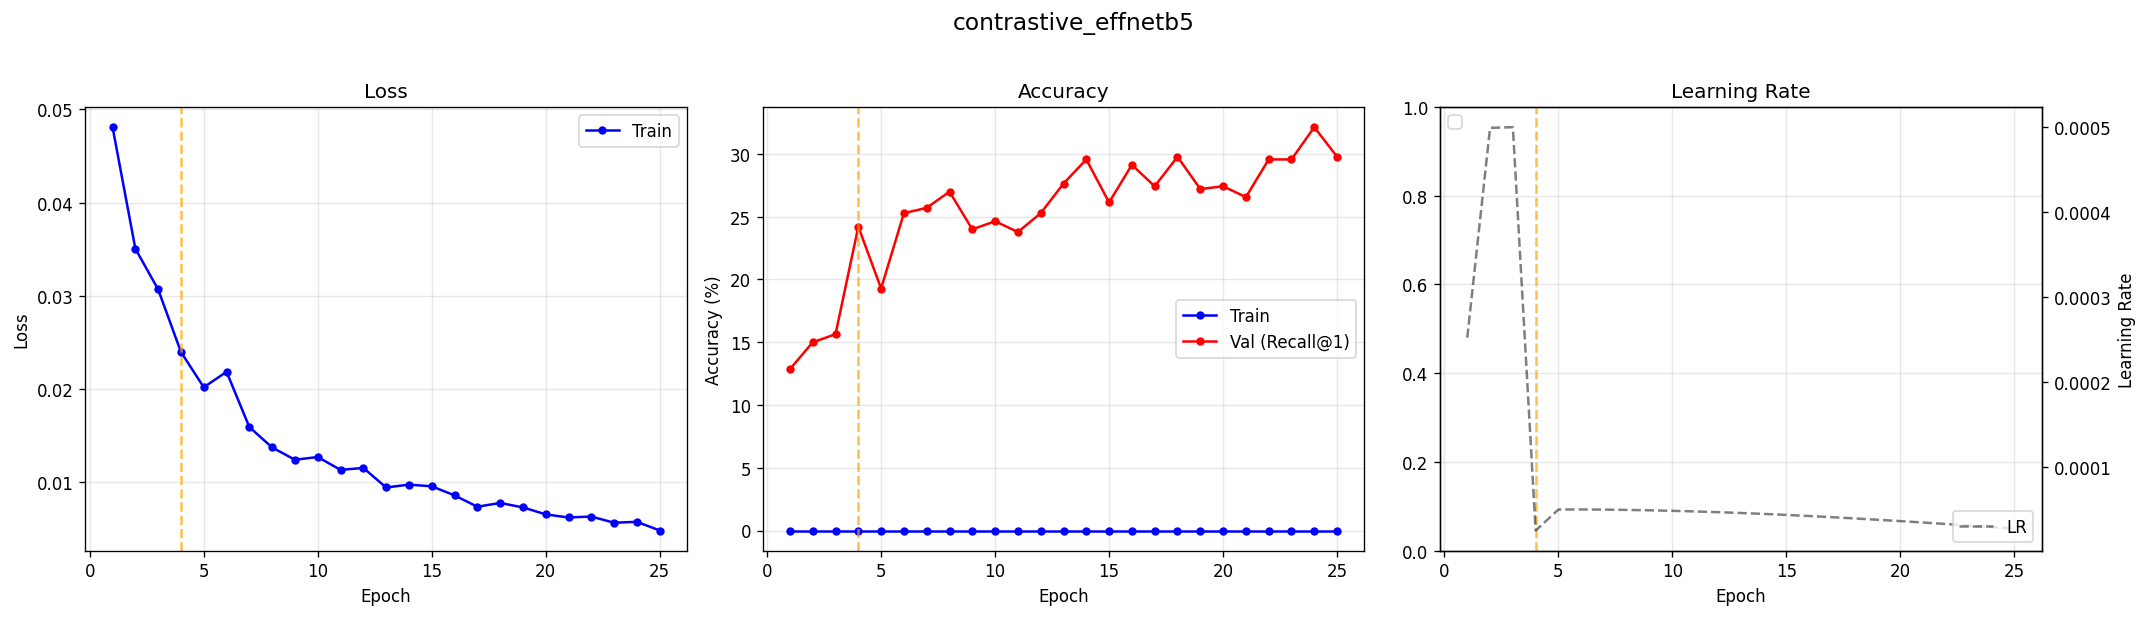

In [5]:
metrics_path = manager.root / "metrics.json"

with open(metrics_path, "r") as f:
    metrics = json.load(f)

plot_training_history(metrics, title=config.experiment_name)

In [6]:
print("\nFinal metrics (last epoch):")
for key in ["retrieval_recall@1", "retrieval_recall@5", "train_loss"]:
    if key in metrics:
        val = metrics[key][-1]
        if "acc" in key or "detection" in key or "recall" in key:
            print(f"  {key:<30s}: {val * 100:.2f}%")
        else:
            print(f"  {key:<30s}: {val:.4f}")



Final metrics (last epoch):
  retrieval_recall@1            : 29.76%
  retrieval_recall@5            : 45.61%
  train_loss                    : 0.0048


### Embedding quality

In [8]:
eval_config, data = get_eval_config_and_data()

model = build_model(config, data["num_classes"], device)
manager.load_checkpoint(model, checkpoint="best")

train_loader, val_loader = build_retrieval_eval_loaders(eval_config, data)

print("Contrastive retrieval performance:")
model_retrieval = evaluate_retrieval(
    model, train_loader, val_loader, eval_config, device,
)

plot_embedding_tsne(model_retrieval, val_loader, data, device,
                    title="Contrastive Loss Embedding — t-SNE", combine_loaders=[train_loader])

[split] Stratified test split infeasible on frequent classes; using shuffled split.
[split] Stratified val split infeasible on frequent classes; using shuffled split.
Dataset split:
  Train:    8089 images, 4247 known classes (filtered 647 new_whale)
  Val:       557 images (88 are new_whale)
  Test:      557 images (75 are new_whale)
  Class distribution: min=1 median=1 max=24 samples/class


[13:31:34] Loading checkpoint: experiments/20260525_114803_contrastive_effnetb5_3a9bca2e/checkpoints/best.pth
[13:31:34] Resuming from epoch 24
Contrastive retrieval performance:


  Extracting embeddings:   0%|          | 0/338 [00:00<?, ?it/s]

  Gallery: 8089 embeddings, 4247 identities


  Extracting embeddings:   0%|          | 0/24 [00:00<?, ?it/s]

  Recall@1: 49.25%  Recall@5: 63.60%  


AttributeError: 'dict' object has no attribute 'eval'